In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import h5py
from matplotlib.lines import Line2D
from matplotlib.ticker import LogLocator
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable
import networkx as nx
from collections import defaultdict
import matplotlib.gridspec as gridspec
import pickle

#get curret folder path in python
from pathlib import Path
out_main = Path.cwd()
out_base = out_main / "figs"
data_base = out_main / "data"
out_base.mkdir(parents=True, exist_ok=True)

In [2]:
# Calculate consistent figure dimensions
fullpage_pt = 597.5 #250.14749*2
inches_per_pt = 1 / 72.27
fig_width_in = fullpage_pt * inches_per_pt
fig_height_per_row = fig_width_in * 0.2
halfpage_pt = 597.5 / 2 #250.14749

In [3]:
# Figure-size helper used throughout this notebook
columnwidth_pt = halfpage_pt

def set_size(width_pt, fraction=1.0, subplots=(1, 1), height_fraction=None):
    """Convert width in pt to a (width, height) tuple in inches.

    If height_fraction is provided, it sets
        height = width * height_fraction.
    Otherwise, height follows the subplots aspect ratio.
    """
    fig_width_pt = width_pt * fraction
    fig_width_in = fig_width_pt * inches_per_pt
    if height_fraction is None:
        fig_height_in = fig_width_in * (subplots[0] / subplots[1])
    else:
        fig_height_in = fig_width_in * height_fraction
    return (fig_width_in, fig_height_in)

In [4]:
mpl.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "text.usetex": True,
    "pgf.rcfonts": False,  # Do not override LaTeX fonts
    "pgf.preamble": "\\usepackage{amsfonts}\n\\usepackage{amssymb}\n\\providecommand{\\mathdefault}[1]{#1}",
    # Used by the LaTeX text rendering path (not just PGF).
    "text.latex.preamble": "\\usepackage{amsfonts}\n\\usepackage{amssymb}",
})

mpl.rcParams.update({
    "text.usetex": True,                 # Use LaTeX to render text
    "font.family": "serif",
    "font.serif": [],                    # Let LaTeX choose (gsajnl will control it)
    "axes.labelsize": 9,                 # Match 9pt document
    "font.size": 7,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

mpl.rcParams.update({
    "lines.linewidth": 0.8,
    "lines.markersize": 3,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
})

# Plot Adaptive Basins

In [5]:
DATA_path = data_base
DATA_peaks = DATA_path / "AdB_peaks_simulations.jld2"
DATA_genotypes = DATA_path / "AdB_genotypes_simulations.jld2"

In [6]:
import numpy as np
from scipy.optimize import root_scalar

def mean_adaptive_basin_size(A, L, omega):
    """
    Calculates the exact asymptotic mean adaptive basin size E[S(omega)] / A^L
    up to O(1/L) including all combinatoric and geometric corrections.
    """
    delta_star = (A - 1) / A
    n = L*(A-1)
    
    # Define exact Gamma and Gamma' functions
    def Gamma(beta, delta):
        return -np.log(A) - beta + delta * np.log(np.exp(A * beta) - 1) + \
               (1 - delta) * np.log(A - 1 + np.exp(A * beta))
               
    def dGamma_dbeta(beta, delta):
        term1 = delta * (A * np.exp(A * beta)) / (np.exp(A * beta) - 1)
        term2 = (1 - delta) * (A * np.exp(A * beta)) / (A - 1 + np.exp(A * beta))
        return -1 + term1 + term2

    # Root finder for beta^*(delta)
    def find_beta_star(delta):
        res = root_scalar(Gamma, args=(delta,), bracket=[1e-5, 5.0], method='brentq')
        return res.root

    # 1. Base values evaluated exactly at the saddle point
    beta_star_val = find_beta_star(delta_star)
    gamma_prime_val = dGamma_dbeta(beta_star_val, delta_star)
    
    # 2. Geometric derivatives via central finite difference
    d_delta = 1e-5
    beta_plus = find_beta_star(delta_star + d_delta)
    beta_minus = find_beta_star(delta_star - d_delta)
    
    beta_prime = (beta_plus - beta_minus) / (2 * d_delta)
    beta_double_prime = (beta_plus - 2 * beta_star_val + beta_minus) / (d_delta**2)
    
    # 3. Assemble the full O(1/L) formula
    
    # O(1) Limit
    term_limit = omega - beta_star_val
    
    # O(ln(L)/L) Combinatoric shift
    term_combinatoric_log = (1 / gamma_prime_val) * (np.log(L) / L)
    
    # O(1/L) Combinatoric shift (using the rigorously non-zero ln(Gamma')!)
    term_combinatoric_sublog = (np.log(gamma_prime_val) / gamma_prime_val) * (1 / L)
    
    # O(1/L) Geometric Variance
    variance_prefactor = (A - 1) / (2 * (A**2) * L)
    term_geom_variance = - variance_prefactor * beta_double_prime
    
    # O(1/L) Geometric Skewness (Vanishes naturally when A=2 due to (A-2))
    skewness_factor = (A * (A - 2)) / (A - 1)
    term_geom_skewness = variance_prefactor * skewness_factor * beta_prime
    
    # 4. Final Result
    expected_basin_size = term_limit + term_combinatoric_log + term_combinatoric_sublog + \
                          term_geom_variance + term_geom_skewness
    
    # The basin size is bounded at 0 if the fitness difference is too low
    return max(0.0, (1 + 1/n) * expected_basin_size)

# --- Example Evaluation ---
#A_val = 2
#L_val = 20
#omega_val = 1.0  # Setting omega = 1.0 to mirror your 1 - beta plots

#result = mean_adaptive_basin_size(A=A_val, L=L_val, omega=omega_val)
#print(f"E[S(ω={omega_val})] / A^L for A={A_val}, L={L_val} is: {result:.5f}")

In [7]:
# Load JLD2 data for plots A and C (adaptive basin genotypes simulations)
def load_adaptive_basin_genotypes_data(jld2_path):
    """
    Load adaptive basin genotype simulation data from JLD2 file using h5py.
    Structure: keys are like "L{L}_A{A}" containing fitness_bins, mean_AdB_size, std_AdB_size
    Returns as nested dict: {A: {L: {'omega': array, 'mean': array, 'std': array}}}
    """
    genotypes_data = {}
    
    with h5py.File(jld2_path, "r") as f:
        for key in sorted(f.keys()):
            # Parse key format: "L{L}_A{A}"
            parts = key.split("_")
            if len(parts) != 2 or not parts[0].startswith("L") or not parts[1].startswith("A"):
                continue
            
            L = int(parts[0][1:])
            A = int(parts[1][1:])
            
            group = f[key]
            fitness = group['fitness_bins'][()]
            mean = group['mean_AdB_size'][()]
            std = group['std_AdB_size'][()]
            
            # Build nested dict structure
            if A not in genotypes_data:
                genotypes_data[A] = {}
            genotypes_data[A][L] = {'omega': fitness, 'mean': mean, 'std': std}
    
    return genotypes_data

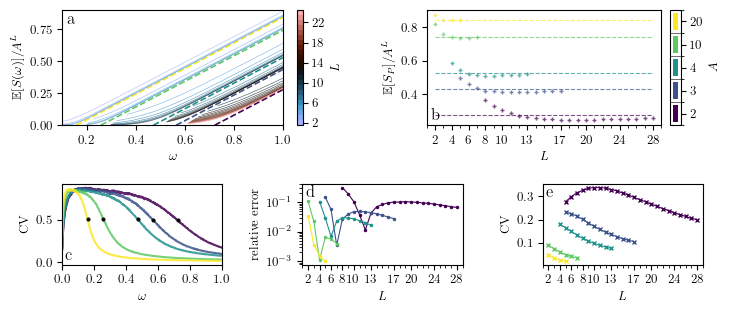

In [8]:
# Load JLD2 data for plot B (adaptive basin peaks simulations)
import h5py
from scipy.optimize import brentq

A_vals = [2, 3, 4, 10, 20]
A_values = A_vals

cmap = mpl.colormaps["viridis"].resampled(len(A_vals))
color_by_A_right = {A: cmap(i) for i, A in enumerate(A_vals)}

# Use the same A colors for panels a and d as defined by the A colorbar
color_by_A_left = color_by_A_right.copy()

x_ticks_manually = [2, 4, 6, 8, 10, 13, 17, 20, 24, 28]

def load_adaptive_basin_peaks_data(jld2_path):
    """Load adaptive basin peak simulation data from JLD2 file using h5py and return as DataFrame."""
    peaks_data = []
    
    with h5py.File(jld2_path, 'r') as f:
        for key in sorted(f.keys()):
            if not key.startswith('A='):
                continue
            
            A = int(key.split('=')[1])
            dataset_val = f[key]
            structured_data = dataset_val[()]
            
            # Get reference to dictionary
            dict_ref = structured_data['kvvec']
            dict_array = f[dict_ref]
            dict_items = dict_array[()]
            
            # Extract L_values, mean_AdB_size, std_AdB_size
            L_values, mean_sizes, std_sizes = None, None, None
            
            for item_ref in dict_items:
                item_obj = f[item_ref]
                key_str = item_obj[()]['first'].decode()
                value_ref = item_obj[()]['second']
                value_obj = f[value_ref]
                value_data = value_obj[()]
                
                if key_str == 'L_values':
                    L_values = value_data
                elif key_str == 'mean_AdB_size':
                    mean_sizes = value_data
                elif key_str == 'std_AdB_size':
                    std_sizes = value_data
            
            # Create DataFrame entries for this A value
            if L_values is not None and mean_sizes is not None:
                for L, mean_val, std_val in zip(L_values, mean_sizes, std_sizes):
                    peaks_data.append({
                        'A': A,
                        'L': int(L),
                        'y': float(mean_val),
                        'std': float(std_val),
                        'series': 'mean'
                    })
    
    return pd.DataFrame(peaks_data)

# return where lines approximately cross
def find_crossover_index(x, f, a_f):
    f_vals = np.array([f(xi) for xi in x])
    idx = 0
    #find first point where f is smaller than a_f and return that index
    while idx < len(x) and f_vals[idx] < a_f[idx]:
        idx += 1

    #print(f"find_crossover_index: final idx={idx}")

    return idx

# Load the data from JLD2 file
df_peaks = load_adaptive_basin_peaks_data(DATA_peaks)
df_genotypes_raw = load_adaptive_basin_genotypes_data(DATA_genotypes)

# ════════════════════════════════════════════════════════════════════════════════
# COMBINED PLOT: Single figure with 2 rows layout
# Top row (a, b) | Bottom row (c, d, e)
# ════════════════════════════════════════════════════════════════════════════════

plt.close('all')

# Legend controls for panel b
showLegendFlag = False
legendXY = (0.8, 0.41)
legendAnchor = "lower center"
legendNcol = 1
legendFontsize = 8
legendFrameon = True

# Set figure height as an explicit fraction of figure width
height_fraction_combined = 0.4

# Layout spacing
top_row_wspace = 0.32
bottom_row_wspace = 0.5
row_hspace = 0.6

# Optional manual bottom-row fine controls
bottom_left_shift = 0.0
extra_gap_before_e = 0.0

fig = plt.figure(figsize=set_size(fullpage_pt, height_fraction=height_fraction_combined))
gs_outer = fig.add_gridspec(2, 1, height_ratios=[1.0, 0.7], hspace=row_hspace)
gs_top = gs_outer[0].subgridspec(1, 2, wspace=top_row_wspace)
gs_bottom = gs_outer[1].subgridspec(1, 3, wspace=bottom_row_wspace)

# Top row
ax_plot_a = fig.add_subplot(gs_top[0, 0])
ax_plot_b = fig.add_subplot(gs_top[0, 1])

# Bottom row (3 panels)
ax_plot_c = fig.add_subplot(gs_bottom[0, 0])
ax_plot_d = fig.add_subplot(gs_bottom[0, 1])
ax_plot_e = fig.add_subplot(gs_bottom[0, 2])

def _shift_axis(ax, dx=0.0, dy=0.0, dw=0.0, dh=0.0):
    p = ax.get_position()
    ax.set_position([p.x0 + dx, p.y0 + dy, p.width + dw, p.height + dh])

if bottom_left_shift != 0.0:
    for _ax in (ax_plot_c, ax_plot_d, ax_plot_e):
        _shift_axis(_ax, dx=-bottom_left_shift)

if extra_gap_before_e != 0.0:
    for _ax in (ax_plot_d, ax_plot_e):
        _shift_axis(_ax, dx=extra_gap_before_e)

#create a dict for the different beta^* values for each A, to plot the dashed lines in panel a
beta_star_by_A = {}
for A in A_vals:
    delta_star = (A - 1) / A
    beta_star = brentq(
        lambda beta: -np.log(A) - beta + delta_star * np.log(np.expm1(A * beta)) + (1 - delta_star) * np.log(A - 1 + np.exp(A * beta)),
        1e-12, 1 - 1e-12
    )
    beta_star_by_A[A] = beta_star

# ── Plot A: Using genotypes data ─────────────────────────────────────────────
# Build L colormap from available genotypes L values
all_L_genotypes = sorted(set(L for A_dict in df_genotypes_raw.values() for L in A_dict.keys()))
cmap_L_plot = mpl.colormaps["berlin"].resampled(len(all_L_genotypes)) #twilight_shifted
color_by_L_plot = {L: cmap_L_plot(i) for i, L in enumerate(all_L_genotypes)}

for Av in A_vals:
    if Av not in df_genotypes_raw:
        continue
    col = color_by_A_left[Av]
    L_dict = df_genotypes_raw[Av]

    # Plot the linear line omega - beta^* for the current A value
    beta_star = beta_star_by_A[Av]
    omega_line = np.linspace(beta_star, 1.0, 100)
    line_values = omega_line - beta_star
    ax_plot_a.plot(omega_line, line_values, linestyle="--", color=col, lw=1.2)

    a_min_L_by_A = {2: 10,
                    3: 7,
                    4: 2,
                    10: 2,
                    20: 2}
    
    # Plot each L value from genotypes data
    for L in sorted(L_dict.keys()):
        if L < a_min_L_by_A.get(Av, 0):
            continue

        data = L_dict[L]
        omega = data['omega']
        mean = data['mean']

        #only do this cutting of if this is not the highest A value
        idx = 0
        if Av != max(A_vals):
            #get next largest A value after Av in A_vals
            Av_p1 = min(a for a in A_vals if a > Av)
            beta_star_p1 = beta_star_by_A[Av_p1]
            def f_analytical(x):
                if x < beta_star_p1:
                    return 0.0
                else:
                    return x - beta_star_p1
                
            #find the crossover point where the numerical mean curve crosses the linear line and cut the data off at that point
            idx = find_crossover_index(omega, f_analytical, mean)
            # a slight shift so it looks a bit better and lines don't tough each other at the crossover point
            idx = idx + 20

        color_L = color_by_L_plot[L]
        ax_plot_a.plot(omega[idx:], mean[idx:], color=color_L, lw=0.5, alpha=0.7)

ax_plot_a.set_xlabel(r"$\omega$")
ax_plot_a.set_ylabel(r"$\mathbb{E}[S(\omega)]/A^L$")
ax_plot_a.set_xlim(0.1, 1.0)
ax_plot_a.set_ylim(0.0, 0.9)
ax_plot_a.text(0.02, 0.98, "a", transform=ax_plot_a.transAxes, fontsize=12, fontweight='bold', va='top', ha='left')

# ── Plot B: Using JLD2 peaks data ────────────────────────────────────────────
min_L = df_peaks["L"].min()
max_L = df_peaks["L"].max()

use_new_analytical_plot_b = True
omega_for_plot_b_analytical = 1.0

for A in sorted(df_peaks["A"].unique()):
    g = df_peaks[df_peaks["A"] == A].sort_values("L")
    color = color_by_A_right[A]

    if A == 2:
            #start only at L=8 for A=2
            g = g[g["L"] >= 8]
    
    # Plot numerical data from JLD2
    ax_plot_b.plot(g["L"], g["y"], marker="+", linestyle="none", color=color, alpha=0.7)

    if use_new_analytical_plot_b:
        L_vals = g["L"].to_numpy(dtype=int)
        y_analytical = np.array([
            mean_adaptive_basin_size(A, int(L), omega_for_plot_b_analytical)
            for L in L_vals
        ], dtype=float)
        delta_star = (A - 1) / A
        beta_star = brentq(
            lambda beta: -np.log(A) - beta + delta_star * np.log(np.expm1(A * beta)) + (1 - delta_star) * np.log(A - 1 + np.exp(A * beta)),
            1e-12, 1 - 1e-12
        )
        ax_plot_b.hlines(1 - beta_star, xmin=min_L, xmax=max_L, linestyle="--", color=color, alpha=0.7)

ax_plot_b.set_xlabel(r"$L$")
ax_plot_b.set_ylabel(r"$\mathbb{E}[S_P]/A^L$")
ax_plot_b.set_xticks(x_ticks_manually)
ax_plot_b.set_xlim(1, 29)
ax_plot_b.xaxis.set_minor_locator(MultipleLocator(1))
ax_plot_b.text(0.02, 0.02, "b", transform=ax_plot_b.transAxes, fontsize=12, fontweight='bold', va='bottom', ha='left')

# Add colorbars for top row
bounds_L = np.arange(-0.5, len(all_L_genotypes) + 0.5, 1)
norm_L = mpl.colors.BoundaryNorm(bounds_L, cmap_L_plot.N)
sm_L = mpl.cm.ScalarMappable(cmap=cmap_L_plot, norm=norm_L)
sm_L.set_array([])
tick_idx = list(range(0, len(all_L_genotypes), max(1, len(all_L_genotypes)//5)))
cbar_L = fig.colorbar(sm_L, ax=ax_plot_a, location="right", shrink=1.0, pad=0.05, ticks=tick_idx)
cbar_L.set_ticklabels([str(all_L_genotypes[i]) for i in tick_idx])
cbar_L.minorticks_off()
cbar_L.set_label(r"$L$", fontsize=9)

bounds_A = np.arange(-0.5, len(A_values) + 0.5, 1)
norm_A = mpl.colors.BoundaryNorm(bounds_A, cmap.N)
sm_A = mpl.cm.ScalarMappable(cmap=cmap, norm=norm_A)
sm_A.set_array([])
cbar_A = fig.colorbar(sm_A, ax=ax_plot_b, location="right", shrink=1.0, pad=0.03, fraction=0.12, aspect=10, ticks=range(len(A_values)), drawedges=True)
cbar_A.set_ticklabels([str(A) for A in A_values])
cbar_A.set_label(r"$A$", fontsize=9)
# ──► RESTORE COLORBAR LINES (white edges) ◄──
cbar_A.solids.set_edgecolor("white")
cbar_A.solids.set_linewidth(3.0)
cbar_A.ax.tick_params(pad=3)

# ── Plot C: CV from genotypes data - ONLY LARGEST L per A ─────────────────────
for Av in sorted(df_genotypes_raw.keys()):
    if Av not in A_values:
        continue
    
    col = color_by_A_left[Av]
    L_dict = df_genotypes_raw[Av]
    
    # Get only the LARGEST L value for this A
    max_L_for_A = max(L_dict.keys())
    data = L_dict[max_L_for_A]
    omega = data['omega']
    mean = data['mean']
    std = data['std']
    
    # Compute CV = std/mean
    cv = np.divide(std, mean, where=mean!=0, out=np.zeros_like(std))
    
    ax_plot_c.plot(omega, cv, color=col, lw=1.5, alpha=0.85)

    #mark the point with a black dot where the CV value at beta^* is located
    beta_star = beta_star_by_A[Av]
    idx_beta_star = np.argmin(np.abs(omega - beta_star))
    ax_plot_c.plot(omega[idx_beta_star], cv[idx_beta_star], marker="o", color="black", markersize=2, alpha=0.9)

ax_plot_c.set_xlabel(r"$\omega$")
ax_plot_c.set_ylabel(r"CV")
ax_plot_c.set_xlim(0.0, 1.0)
ax_plot_c.xaxis.set_major_locator(MultipleLocator(0.2))
ax_plot_c.text(0.02, 0.2, "c", transform=ax_plot_c.transAxes, fontsize=12, fontweight='bold', va='top', ha='left')

# ── Plot D: Relative error of numerical mean vs 1-β* ──────────────────────────
for A in sorted(df_peaks["A"].unique()):
    g = df_peaks[df_peaks["A"] == A].sort_values("L")
    if A == 2:
            #start only at L=8 for A=2
            g = g[g["L"] >= 8]

    color = color_by_A_right[A]
    
    beta_star  = beta_star_by_A[A]
    one_minus_beta_star = 1 - beta_star
    rel_err = np.abs(g["y"].to_numpy(dtype=float) - one_minus_beta_star) / one_minus_beta_star
    ax_plot_d.plot(g["L"], rel_err, marker=".", linestyle="-", color=color)

ax_plot_d.set_xlabel(r"$L$")
ax_plot_d.set_ylabel(r"relative error")
ax_plot_d.set_yscale("log")
ax_plot_d.set_xticks(x_ticks_manually)
ax_plot_d.set_xlim(1, 29)
ax_plot_d.xaxis.set_minor_locator(MultipleLocator(1))
ax_plot_d.text(0.02, 0.98, "d", transform=ax_plot_d.transAxes, fontsize=12, fontweight='bold', va='top', ha='left')

# ── Plot E: CV of peaks ──────────────────────────────────────────────────────
for A in sorted(df_peaks["A"].unique()):
    g = df_peaks[df_peaks["A"] == A].sort_values("L")
    color = color_by_A_right[A]
    # Calculate coefficient of variation
    cv_vals = g["std"].to_numpy() / g["y"].to_numpy()
    ax_plot_e.plot(g["L"], cv_vals, marker="x", linestyle="-", color=color)

ax_plot_e.set_xlabel(r"$L$")
ax_plot_e.set_ylabel(r"CV")
ax_plot_e.set_xticks(x_ticks_manually)
ax_plot_e.set_xlim(1, 29)
ax_plot_e.xaxis.set_minor_locator(MultipleLocator(1))
ax_plot_e.text(0.02, 0.98, "e", transform=ax_plot_e.transAxes, fontsize=12, fontweight='bold', va='top', ha='left')

# ══════════════════════════════════════════════════════════════════════════════
# EXPORT SINGLE COMBINED FIGURE
# ══════════════════════════════════════════════════════════════════════════════

fig.savefig(out_base / "AdaptiveBasin.pgf", backend="pgf", bbox_inches='tight')
plt.show()


# Plot Beta

l* / delta^* for A=2: 1.6140
l* / delta^* for A=3: 1.8481
l* / delta^* for A=4: 2.0280
l* / delta^* for A=10: 2.6748
l* / delta^* for A=20: 3.2308


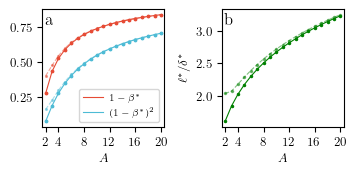

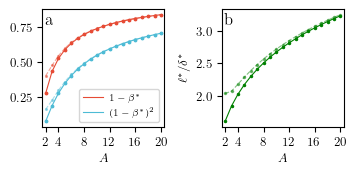

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# 1x2 FIGURE: Beta (left) and macroscopic path length l* (right)
# ══════════════════════════════════════════════════════════════════════════════

fig_beta_lstar = plt.figure(figsize=set_size(columnwidth_pt*0.85, subplots=(1, 2)))
gs_beta_lstar = gridspec.GridSpec(1, 2, figure=fig_beta_lstar)

ax_left_beta = fig_beta_lstar.add_subplot(gs_beta_lstar[0, 0])
ax_right_lstar = fig_beta_lstar.add_subplot(gs_beta_lstar[0, 1])

# ── LEFT PANEL: Beta (1-β* and (1-β*)^2) ──
from scipy.optimize import brentq

# Define the objective function: Γ_full(β, δ, A)
def Gamma_full(beta, delta, A):
    """
    Γ_full(β, δ, A) = -log(A) - β + δ * log(exp(A*β) - 1) + (1-δ) * log(exp(A*β) + A - 1)
    Uses expm1 for numerical stability near β≈0.
    """
    eAb = np.expm1(A * beta)  # exp(A*β) - 1, numerically stable
    exp_Ab = eAb + 1           # exp(A*β)
    return -np.log(A) - beta + delta * np.log(eAb) + (1 - delta) * np.log(exp_Ab + A - 1)

# Define the large-A approximation
def beta_largeA(A):
    """
    Large-A approximation: β*(A) ≈ ln(A)/A + (ln(A) + 1 - ln(2))/A^2
    """
    return np.log(A) / A + (np.log(A) + 1 - np.log(2)) / A**2

# Define A range for the plot
A_min = 2
A_max = 20
A_range_plot = np.arange(A_min, A_max + 1)

# Compute exact β* via root finding
beta_exact = []
for A in A_range_plot:
    delta_star = (A - 1) / A
    beta_root = brentq(lambda beta: Gamma_full(beta, delta_star, A), 1e-12, 1 - 1e-12)
    beta_exact.append(beta_root)

beta_exact = np.array(beta_exact)

# Compute β̃* (large-A approximation)
beta_approx = np.array([beta_largeA(A) for A in A_range_plot])

# Compute (1-β*)^2 (both exact and approximation)
beta_sq_exact = (1 - beta_exact) ** 2
beta_sq_approx = (1 - beta_approx) ** 2

# Colors
col_1minus_beta = "#E64B35"   # Red for 1 - β*
col_beta_sq     = "#4DBBD5"   # Teal for (1-β*)^2

# Manually select which A values appear on the x-axis ticks
A_ticks = [2, 4, 8, 12, 16, 20]

# Alpha value for approximation curves
alpha_approx = 0.5

# Plot 1 - β* (numerical and approximation)
ax_left_beta.plot(A_range_plot, 1 - beta_exact, color=col_1minus_beta, alpha=1, label=r"$1-\beta^*$")
for i, (A, y) in enumerate(zip(A_range_plot, 1 - beta_exact)):
    ax_left_beta.plot(A, y, color=col_1minus_beta, marker=".", markersize=3.5, alpha=1)

ax_left_beta.plot(A_range_plot, 1 - beta_approx, color=col_1minus_beta, alpha=alpha_approx, linestyle="--")
for i, (A, y) in enumerate(zip(A_range_plot, 1 - beta_approx)):
    ax_left_beta.plot(A, y, color=col_1minus_beta, marker=".", markersize=2.5, alpha=alpha_approx)

# Plot (1-β*)^2 (numerical and approximation)
ax_left_beta.plot(A_range_plot, beta_sq_exact, color=col_beta_sq, alpha=1, label=r"$(1-\beta^*)^2$")
for i, (A, y) in enumerate(zip(A_range_plot, beta_sq_exact)):
    ax_left_beta.plot(A, y, color=col_beta_sq, marker=".", markersize=3.5, alpha=1)

ax_left_beta.plot(A_range_plot, beta_sq_approx, color=col_beta_sq, alpha=alpha_approx, linestyle="--")
for i, (A, y) in enumerate(zip(A_range_plot, beta_sq_approx)):
    ax_left_beta.plot(A, y, color=col_beta_sq, marker=".", markersize=2.5, alpha=alpha_approx)

ax_left_beta.set_xlabel(r'$A$', fontsize=9, fontweight='bold')
#ax_left_beta.set_ylabel(r'$\beta^*$ properties', fontsize=9, fontweight='bold')
from matplotlib.ticker import FixedLocator
ax_left_beta.xaxis.set_major_locator(FixedLocator(A_ticks))
ax_left_beta.set_xlim(A_min - 0.5, A_max + 0.5)
ax_left_beta.legend(loc="lower right", fontsize=7, frameon=True)
ax_left_beta.text(0.02, 0.97, "a", transform=ax_left_beta.transAxes, fontsize=12, fontweight='bold', va='top', ha='left')

# ── RIGHT PANEL: Macroscopic path length l* ──
# Exact macroscopic path length and its large-A approximations.
def exact_l_star(A):
    delta = (A - 1) / A

    def Gamma(beta):
        return -np.log(A) - beta + delta * np.log(np.exp(A * beta) - 1) + (1 - delta) * np.log(A - 1 + np.exp(A * beta))

    def Gamma_prime(beta):
        term1 = delta * (A * np.exp(A * beta)) / (np.exp(A * beta) - 1)
        term2 = (1 - delta) * (A * np.exp(A * beta)) / (A - 1 + np.exp(A * beta))
        return -1 + term1 + term2

    res = brentq(Gamma, 1e-12, 1 - 1e-12)
    return Gamma_prime(res) * res

l_delta_star_exact = np.array([exact_l_star(A) / ((A-1)/A) for A in A_range_plot])

for A_t in A_range_plot:
    if A_t in [2, 3, 4, 10, 20]:
        val = l_delta_star_exact[A_t - A_min]
        print(f"l* / delta^* for A={A_t}: {val:.4f}")

l_star_approx = (np.log(A_range_plot) + (2 + np.log(A_range_plot / 4)) / (2 * A_range_plot)) / ((A_range_plot - 1) / A_range_plot)

ax_right_lstar.plot(A_range_plot, l_delta_star_exact, marker=".", color="green", label=r"exact $\ell^*$")
ax_right_lstar.plot(A_range_plot, l_star_approx, marker=".", color="green", linestyle="--", label=r"$\mathcal{O}(1/A)$", alpha=alpha_approx)
ax_right_lstar.set_xlabel(r'$A$', fontsize=9, fontweight='bold')
ax_right_lstar.set_ylabel(r"$\ell^* / \delta^*$", fontsize=9, fontweight='bold')
ax_right_lstar.set_xlim(A_min - 0.5, A_max + 0.5)
ax_right_lstar.set_xticks(A_ticks)
ax_right_lstar.text(0.02, 0.97, "b", transform=ax_right_lstar.transAxes, fontsize=12, fontweight='bold', va='top', ha='left')

plt.tight_layout()

# ── save PGF ──
fig_beta_lstar.savefig(f"{out_base}/Beta.pgf", backend="pgf")

# Display the figure
fig_beta_lstar

# Plot Gradient and Adaptive Difference + Rank Order

### Gradient and Adaptive Basin Difference Plot

Adaptive basin sizes:
  Peak 1111: 14 inside -> ['0000', '0010', '0100', '0101', '0110', '0111', '1000', '1001', '1010', '1011', '1100', '1101', '1110', '1111']
           2 outside -> ['0001', '0011']
  Peak 0001: 15 inside -> ['0000', '0001', '0010', '0011', '0100', '0101', '0110', '0111', '1000', '1001', '1010', '1011', '1100', '1101', '1110']
           1 outside -> ['1111']


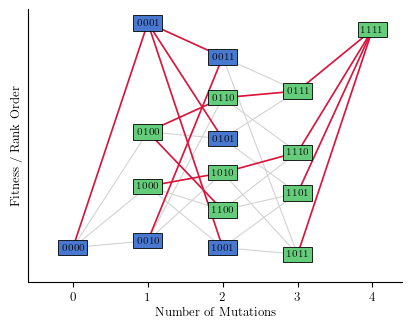

In [10]:
fitness_by_genotype_L4 = {
    # 0 mutations
    "0000": 0.08,
    # 1 mutation
    "0001": 0.41,  # peak 1
    "0010": 0.09,
    "0100": 0.25,
    "1000": 0.17,
    # 2 mutations
    "0011": 0.36,
    "0101": 0.24,
    "0110": 0.3,
    "1001": 0.08,
    "1010": 0.19,
    "1100": 0.135,
    # 3 mutations
    "0111": 0.31,
    "1011": 0.07,
    "1101": 0.16,
    "1110": 0.22,
    # 4 mutations
    "1111": 0.40,  # peak 2
}

# ── helpers ───────────────────────────────────────────────────────────────────
def hamming(a, b):
    return sum(x != y for x, y in zip(a, b))

genotypes_L4 = list(fitness_by_genotype_L4.keys())

# ── Build undirected hypercube graph ──────────────────────────────────────────
H = nx.Graph()
H.add_nodes_from(genotypes_L4)
for i, g1 in enumerate(genotypes_L4):
    for g2 in genotypes_L4[i + 1:]:
        if hamming(g1, g2) == 1:
            H.add_edge(g1, g2)

# ── Node positions: x = hamming weight, y = fitness ───────────────────────────
pos_L4 = {g: (g.count("1"), fitness_by_genotype_L4[g]) for g in genotypes_L4}

# ── Best uphill step (greedy / steepest-ascent) ───────────────────────────────
greedy_successor = {}
for g in genotypes_L4:
    best, best_delta = None, 0.0
    for nb in H.neighbors(g):
        delta = fitness_by_genotype_L4[nb] - fitness_by_genotype_L4[g]
        if delta > best_delta:
            best_delta, best = delta, nb
    greedy_successor[g] = best

red_arrows = [(g, s) for g, s in greedy_successor.items() if s is not None]

# ── Greedy basins ─────────────────────────────────────────────────────────────
peaks = {"0001", "1111"}

def greedy_peak(g):
    visited = set()
    while g is not None and g not in visited:
        if g in peaks:
            return g
        visited.add(g)
        g = greedy_successor.get(g)
    return None

greedy_basin = {p: set() for p in peaks}
for g in genotypes_L4:
    p = greedy_peak(g)
    if p is not None:
        greedy_basin[p].add(g)

# ── Adaptive basins ───────────────────────────────────────────────────────────
DG = nx.DiGraph()
DG.add_nodes_from(genotypes_L4)
for uu, vv in H.edges():
    if fitness_by_genotype_L4[vv] > fitness_by_genotype_L4[uu]:
        DG.add_edge(uu, vv)
    if fitness_by_genotype_L4[uu] > fitness_by_genotype_L4[vv]:
        DG.add_edge(vv, uu)

adaptive_basin = {}
for p in peaks:
    anc = nx.ancestors(DG, p); anc.add(p)
    adaptive_basin[p] = anc

all_genotypes = set(genotypes_L4)
print("Adaptive basin sizes:")
for p in peaks:
    inside  = sorted(adaptive_basin[p])
    outside = sorted(all_genotypes - adaptive_basin[p])
    print(f"  Peak {p}: {len(inside)} inside -> {inside}")
    print(f"           {len(outside)} outside -> {outside}")

# ── Node colours ──────────────────────────────────────────────────────────────
col_0001 = "#4878CF"; col_1111 = "#65CC7B"; col_both = "#B47CC7"; col_none = "white"

def node_facecolor(g):
    in_0001 = g in greedy_basin["0001"]
    in_1111 = g in greedy_basin["1111"]
    if in_0001 and in_1111: return col_both
    if in_0001:              return col_0001
    if in_1111:              return col_1111
    return col_none

# ── Reusable drawing function ─────────────────────────────────────────────────
def draw_landscape(ax):
    for uu, vv in H.edges():
        xu, yu = pos_L4[uu]; xv, yv = pos_L4[vv]
        ax.plot([xu, xv], [yu, yv], color="lightgrey", linewidth=0.8, zorder=1)
    for src, dst in red_arrows:
        xs, ys = pos_L4[src]; xd, yd = pos_L4[dst]
        ax.plot([xs, xd], [ys, yd], color="crimson", lw=1.2, zorder=3)
    for g in genotypes_L4:
        x, y = pos_L4[g]
        ax.text(x, y, g, ha="center", va="center", color="black", zorder=5,
                bbox=dict(boxstyle="square,pad=0.35", facecolor=node_facecolor(g),
                          edgecolor="black", linewidth=0.6))
    ax.set_xlabel(r"Number of Mutations")
    ax.set_ylabel(r"Fitness / Rank Order")
    ax.set_xticks([0, 1, 2, 3, 4])
    ax.set_xlim(-0.6, 4.4)
    ax.set_ylim(0.03, 0.43)
    ax.set_yticks([])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ── Standalone preview ────────────────────────────────────────────────────────
fig_g, ax_g = plt.subplots(figsize=set_size(columnwidth_pt, subplots=(2, 2.5)))
draw_landscape(ax_g)
fig_g.tight_layout()
#fig_g.savefig(out_base + "MutationsFitness.pgf", bbox_inches="tight", backend="pgf")
plt.show()

### Rank Order Plot

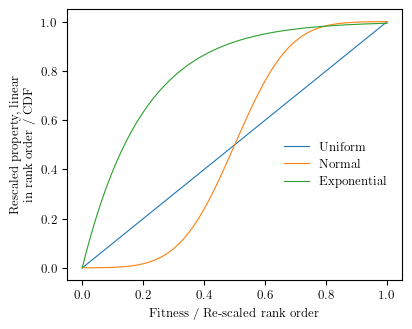

In [11]:
from scipy.stats import norm as _scipy_norm

lo, hi = 0.0001, 0.9999
u = np.linspace(lo, hi, 2000)

# ── Distribution parameters ───────────────────────────────────────────────────
lam   = 5.0   # Exponential rate parameter
mu    = 0.5   # Normal mean
sigma2 = 0.02  # Normal variance

q_unif = u
q_exp  = 1 - np.exp(-lam * u)
q_norm = _scipy_norm.cdf(u, loc=mu, scale=np.sqrt(sigma2))

def robust_rescale(x):
    x_lo = np.quantile(x, lo); x_hi = np.quantile(x, hi)
    return (x - x_lo) / (x_hi - x_lo)

P_unif_s = robust_rescale(q_unif)
P_exp_s  = robust_rescale(q_exp)
P_norm_s = robust_rescale(q_norm)

# ── Legend controls ───────────────────────────────────────────────────────────
# legendXY is in axes coordinates: (0,0)=bottom-left, (1,1)=top-right.
# Values outside [0,1] place the legend outside the plot area.
# legendAnchor: which corner of the legend box is anchored at legendXY:
#   "upper left", "upper right", "lower left", "lower right", "center left", etc.
# Examples:
#   legendXY=(1.02, 1.0),  legendAnchor="upper left"   → outside, top-right
#   legendXY=(0.5,  -0.2), legendAnchor="upper center" → below the plot, centred
     # (x, y) in axes coordinates
legendAnchor  = "lower center"  # which corner of the legend box goes to legendXY
legendXY      = (0.8, 0.3)
legendNcol    = 1               # all three entries in one row → minimal vertical space
legendFontsize = None          # None = rcParam default; or e.g. 8
legendFrameon  = False          # draw legend box border?

# ── Reusable drawing function ─────────────────────────────────────────────────
def draw_rank_order(ax):
    ax.plot(u, q_unif, label="Uniform")
    ax.plot(u, q_norm, label="Normal") #($\mu={mu}$, $\sigma^2={sigma2}$)
    ax.plot(u, q_exp,  label="Exponential") #($\lambda={lam}$)
    ax.set_xlabel("Fitness / Re-scaled rank order")
    ax.set_ylabel("Rescaled property, linear\nin rank order / CDF")

# ── Standalone preview ────────────────────────────────────────────────────────
mplt_ro, ax_ro = plt.subplots(figsize=set_size(columnwidth_pt, subplots=(2, 2.5)))
draw_rank_order(ax_ro)

legend_kwargs = dict(
    loc=legendAnchor,
    bbox_to_anchor=legendXY,
    bbox_transform=ax_ro.transAxes,
    ncol=legendNcol,
    frameon=legendFrameon,
)
if legendFontsize is not None:
    legend_kwargs["fontsize"] = legendFontsize
ax_ro.legend(**legend_kwargs)

mplt_ro.tight_layout()

#mplt_ro.savefig(out_dresden + "RankOrder.pgf", bbox_inches="tight", backend="pgf")

plt.show()

### Combine both plots

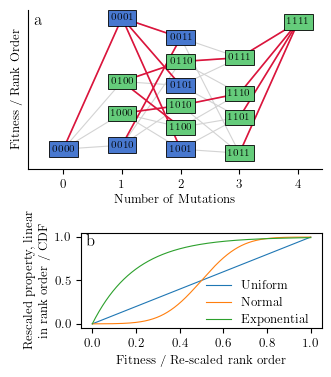

In [12]:
plt.close('all')

# -- Combined: landscape (top) + rank order (bottom) --------------------------
fig_combined = plt.figure(figsize=set_size(columnwidth_pt, height_fraction=1.0, subplots=(1.45, 1)))
gs = fig_combined.add_gridspec(
    2, 12,
    height_ratios=[1.5, 0.9],
    hspace=0.5,
    wspace=0.0,
 )

# Let the top panel use more horizontal space; bottom can stay narrower.
ax_land = fig_combined.add_subplot(gs[0, 0:11])
ax_ro   = fig_combined.add_subplot(gs[1, 2:11])

draw_landscape(ax_land)
draw_rank_order(ax_ro)

# Panel labels (upper-left), matching the larger multi-panel figure style.
ax_land.text(0.02, 0.98, "a", transform=ax_land.transAxes, fontsize=12, fontweight='bold', va='top', ha='left')
ax_ro.text(0.02, 0.98, "b", transform=ax_ro.transAxes, fontsize=12, fontweight='bold', va='top', ha='left')

# Explicit legend for the lower panel in the combined figure.
ax_ro.legend(
    loc="upper center",
    bbox_to_anchor=(0.73, 0.62),
    ncol=1,
    frameon=False,
    fontsize=9,
 )

import os; os.makedirs(out_base, exist_ok=True)
fig_combined.savefig(out_base / "LandscapeAndRankOrder.pgf", bbox_inches="tight", backend="pgf")
plt.show()


# Gradient Plot

In [13]:
mpl.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "text.usetex": True,
    "pgf.rcfonts": False,  # Do not override LaTeX fonts
    "pgf.preamble": r'\usepackage{amsfonts}\usepackage{amssymb}',
    # Used by the LaTeX text rendering path (not just PGF).
    "text.latex.preamble": "\\usepackage{amsfonts}\\usepackage{amssymb}",
})

mpl.rcParams.update({
    "text.usetex": True,                 # Use LaTeX to render text
    "font.family": "serif",
    "font.serif": [],                    # Let LaTeX choose (gsajnl will control it)
    "axes.labelsize": 9,                 # Match 9pt document
    "font.size": 7,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

# ── Configure matplotlib for PGF output ──
mpl.rcParams.update({
    'font.family': 'serif',
    'font.size': 9,
    'pgf.preamble': r'\usepackage{amsfonts}\usepackage{amssymb}',
    'pgf.texsystem': 'pdflatex',
})

# Note: The pgf.preamble above must use single backslashes when rendered by LaTeX.
# Using a raw string with single backslashes ensures the LaTeX header is valid.

In [14]:
# Rebuild the gradient-basin inputs from the HDF5 file that the plotting cell expects.
GRADIENT_DATA = data_base / "gradient_basin_data_f_run.h5"
GRADIENT_DATA_EXTRACTED = data_base / "gradient_basin_data_extracted.pkl"

#The figure is currently built for the A-series to highlight in the top row.
A_main = 4
a_L_main = [20, 40, 60, 80, 100]
#The x-axis limits are shared by the top panel and the relative-error panel.

In [15]:
# Code that is commented out is for extracting the needed data from the HDF5 file and saving it in a more convenient format for plotting.

In [16]:
def basin_analytical(omega, n):
    return 1.0 + n * np.power(omega, n - 1) * np.exp(np.power(omega, n - 1))

"""
def _load_gradient_series(group):
    # Each fitness_map entry stores 20000 basin-size samples for one fitness value.
    fitness_values = []
    mean_basin_values = []
    std_basin_values = []

    for entry in group["fitness_map"].values():
        # Fitness is scalar per entry; basin_sizes is the repeated Monte Carlo sample array.
        fitness = float(np.ravel(np.array(entry["fitness"], dtype=float))[0])
        basin_sizes = np.ravel(np.array(entry["basin_sizes"], dtype=float))
        fitness_values.append(fitness)
        # Store the empirical mean and spread so the plot can reproduce the original curves.
        mean_basin_values.append(float(np.mean(basin_sizes)))
        std_basin_values.append(float(np.std(basin_sizes, ddof=1)))

    # Sort by fitness so downstream lines and error calculations are monotone in x.
    order = np.argsort(fitness_values)
    fitness_values = np.asarray(fitness_values, dtype=float)[order]
    mean_basin_values = np.asarray(mean_basin_values, dtype=float)[order]
    std_basin_values = np.asarray(std_basin_values, dtype=float)[order]

    return fitness_values, mean_basin_values, std_basin_values


# These dictionaries recreate the inputs that the plot cell needs for the three panels.
top_panel_data = {}
all_panel_data = {}
bottom_left_panel_data = {}
error_per_L = {}
max_errors = {}
cv = {}
config_main = []
config_maxerror = []

with h5py.File(GRADIENT_DATA, "r") as fh:
    # Walk every L/A group in the file and rebuild the exact variables used by the figure.
    for grp_name in sorted(fh.keys()):
        match = re.fullmatch(r"L(\d+)_A(\d+)", grp_name)
        if match is None:
            continue

        L = int(match.group(1))
        A = int(match.group(2))
        n = L * (A - 1)

        mids, means, stds = _load_gradient_series(fh[grp_name])
        all_panel_data[(L, A)] = (mids, means, n)

        # Compare the empirical mean to the asymptotic expression to recover the error curves.
        theory = basin_analytical(mids, n)
        rel_err = np.abs(theory - means) / np.maximum(means, np.finfo(float).tiny)
        max_errors[(L, A)] = float(np.max(rel_err))
        config_maxerror.append((L, A))
        
        #for each pair of L and A store the coefficient of variantions for their respective series of basin sizes
        cv[(L, A)] = np.asarray(stds) / np.maximum(np.asarray(means), np.finfo(float).tiny)

        if A == A_main:
            if L in a_L_main:
                config_main.append(L)
                # error_per_L is the bottom-left panel input: one error curve per L.
                error_per_L[L] = (mids, rel_err)

                # top_panel_data stores the raw series plus the n used by the analytical curve.
                top_panel_data[(L, A)] = (mids, means, n)


# Convert the collected keys into the simple lists the plotting cell expects.
config_main = sorted(config_main)
config_maxerror = sorted(config_maxerror)
Ls = config_main.copy()
A_values_all = sorted({A for _, A in config_maxerror})

cmap_L = mpl.colormaps["twilight_shifted"].resampled(len(Ls))
color_by_L = {L: cmap_L(i) for i, L in enumerate(Ls)}

cmap_A = mpl.colormaps["viridis"].resampled(len(A_values_all))
color_by_A = {A: cmap_A(i) for i, A in enumerate(A_values_all)}

print(f"Loaded gradient basin data")
print(f"A_main = {A_main}")
print(f"config_main = {config_main}")
print(f"config_maxerror = {config_maxerror}")
"""

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
/var/folders/3n/55z6qmb11jbgtr6rg7_r_wb00000gn/T/ipykernel_12277/1593561830.py:4: SyntaxWarning: invalid escape sequence '\d'
  """


'\ndef _load_gradient_series(group):\n    # Each fitness_map entry stores 20000 basin-size samples for one fitness value.\n    fitness_values = []\n    mean_basin_values = []\n    std_basin_values = []\n\n    for entry in group["fitness_map"].values():\n        # Fitness is scalar per entry; basin_sizes is the repeated Monte Carlo sample array.\n        fitness = float(np.ravel(np.array(entry["fitness"], dtype=float))[0])\n        basin_sizes = np.ravel(np.array(entry["basin_sizes"], dtype=float))\n        fitness_values.append(fitness)\n        # Store the empirical mean and spread so the plot can reproduce the original curves.\n        mean_basin_values.append(float(np.mean(basin_sizes)))\n        std_basin_values.append(float(np.std(basin_sizes, ddof=1)))\n\n    # Sort by fitness so downstream lines and error calculations are monotone in x.\n    order = np.argsort(fitness_values)\n    fitness_values = np.asarray(fitness_values, dtype=float)[order]\n    mean_basin_values = np.asarray

In [17]:
"""

# Path for extracted data
GRADIENT_DATA_EXTRACTED = data_base / "gradient_basin_data_extracted.pkl"

# ─────────────────────────────────────────────────────────────────
# SAVE (after extracting all variables)
# ─────────────────────────────────────────────────────────────────
extracted_data = {
    'top_panel_data': top_panel_data,
    'all_panel_data': all_panel_data,
    'bottom_left_panel_data': bottom_left_panel_data,
    'error_per_L': error_per_L,
    'max_errors': max_errors,
    'cv': cv,
    'config_main': config_main,
    'config_maxerror': config_maxerror,
    'color_by_L': color_by_L,
    'color_by_A': color_by_A,
}

with open(GRADIENT_DATA_EXTRACTED, 'wb') as f:
    pickle.dump(extracted_data, f)

file_size_mb = GRADIENT_DATA_EXTRACTED.stat().st_size / 1e6
print(f"Saved gradient data to {GRADIENT_DATA_EXTRACTED.name} ({file_size_mb:.1f} MB)")
"""

'\n\n# Path for extracted data\nGRADIENT_DATA_EXTRACTED = data_base / "gradient_basin_data_extracted.pkl"\n\n# ─────────────────────────────────────────────────────────────────\n# SAVE (after extracting all variables)\n# ─────────────────────────────────────────────────────────────────\nextracted_data = {\n    \'top_panel_data\': top_panel_data,\n    \'all_panel_data\': all_panel_data,\n    \'bottom_left_panel_data\': bottom_left_panel_data,\n    \'error_per_L\': error_per_L,\n    \'max_errors\': max_errors,\n    \'cv\': cv,\n    \'config_main\': config_main,\n    \'config_maxerror\': config_maxerror,\n    \'color_by_L\': color_by_L,\n    \'color_by_A\': color_by_A,\n}\n\nwith open(GRADIENT_DATA_EXTRACTED, \'wb\') as f:\n    pickle.dump(extracted_data, f)\n\nfile_size_mb = GRADIENT_DATA_EXTRACTED.stat().st_size / 1e6\nprint(f"Saved gradient data to {GRADIENT_DATA_EXTRACTED.name} ({file_size_mb:.1f} MB)")\n'

In [18]:
# ─────────────────────────────────────────────────────────────────
# LOAD (in future runs)
# ─────────────────────────────────────────────────────────────────
with open(GRADIENT_DATA_EXTRACTED, 'rb') as f:
    extracted_data = pickle.load(f)

top_panel_data = extracted_data['top_panel_data']
all_panel_data = extracted_data['all_panel_data']
bottom_left_panel_data = extracted_data['bottom_left_panel_data']
error_per_L = extracted_data['error_per_L']
max_errors = extracted_data['max_errors']
cv = extracted_data['cv']
config_main = extracted_data['config_main']
config_maxerror = extracted_data['config_maxerror']
color_by_L = extracted_data['color_by_L']
color_by_A = extracted_data['color_by_A']

print(f"Loaded gradient data from {GRADIENT_DATA_EXTRACTED.name}")

Loaded gradient data from gradient_basin_data_extracted.pkl


/var/folders/3n/55z6qmb11jbgtr6rg7_r_wb00000gn/T/ipykernel_12277/2023140676.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_L = plt.cm.get_cmap("plasma")


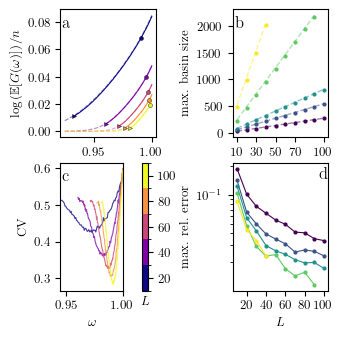

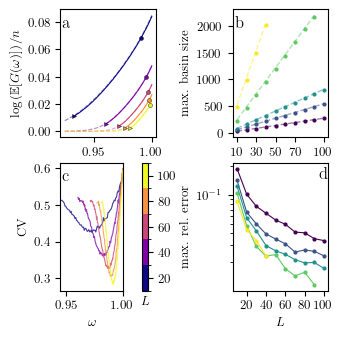

In [19]:
omega_min_top = 0.925
omega_min_bottom_left = 0.945
omega_max = 1.0

# ── create figure with gridspec ──
#fig_width_in = halfpage_pt * inches_per_pt

fig = plt.figure(figsize=set_size(columnwidth_pt*0.8))
gs = gridspec.GridSpec(2, 2, figure=fig, height_ratios=[1, 1]) #, width_ratios=[1, 1]

ax_top = fig.add_subplot(gs[0, 0])
ax_top_right = fig.add_subplot(gs[0, 1])  
ax_bottom_left = fig.add_subplot(gs[1, 0])
ax_bottom_right = fig.add_subplot(gs[1, 1])

from scipy.special import lambertw

def yaxis_transform(x, L, A):
    n = L * (A - 1)
    return np.log(x) / n #x / np.sqrt(n) #np.log(x)

# ══════════════════════════════════════════════════════════════════════════
# TOP LEFT: Gradient basin size vs ω for selected (L, A) pairs, with analytical curves and markers
# ══════════════════════════════════════════════════════════════════════════

Ls_in_data = sorted({L for (L, A) in top_panel_data.keys()})
cmap_L = plt.cm.get_cmap("plasma")

# Bounds and norm for only the data that exists
bounds_L = np.arange(len(Ls_in_data) + 1) - 0.5
norm_L = mpl.colors.BoundaryNorm(bounds_L, cmap_L.N)
sm_L = mpl.cm.ScalarMappable(cmap=cmap_L, norm=norm_L)
sm_L.set_array([])

# Colorbar with correct tick labels
cbar_L = fig.colorbar(sm_L, ax=ax_bottom_left, shrink=1.0, pad=0.2)
cbar_L.set_ticks(np.arange(len(Ls_in_data)))
cbar_L.set_ticklabels([str(L) for L in Ls_in_data], fontsize=9)
cbar_L.ax.set_xlabel('$L$')

#get colos for plot from the cbar
color_by_L = {}
for i, L in enumerate(Ls_in_data):
    color_by_L[L] = cmap_L(norm_L(i))


#color_by_L = {L: cbar_L(i) for i, L in enumerate(Ls)}

for L in config_main:
    A = A_main
    if (L, A) not in top_panel_data:
        continue
    
    mids, means, n = top_panel_data[(L, A)]
    col = color_by_L[L]
    
    # Plot simulation data (continuous line)
    ax_top.plot(mids, yaxis_transform(means, L, A), color=col, linewidth=0.8)
    
    # Plot analytical curve
    omegas = np.linspace(omega_min_top, omega_max, 500)
    analytical_vals = basin_analytical(omegas, n)
    ax_top.plot(omegas, yaxis_transform(analytical_vals, L, A), 
                linestyle='--', linewidth=0.8, alpha=0.5, color=col)

    # Mark omega* = W(1)^(1/(n-1)) on each top-panel curve
    omega_star = float(np.real(lambertw(1.0))) ** (1.0 / (n - 1))
    y_star = yaxis_transform(basin_analytical(omega_star, n), L, A)
    ax_top.scatter([omega_star], [y_star], s=8, color=col, edgecolors='black', linewidths=0.3, zorder=6)

    # Mark the point where E[G(omega)] = 2
    omega_thresh = float(np.real(lambertw(1.0 / n))) ** (1.0 / (n - 1))
    y_thresh = yaxis_transform(2, L, A)
    ax_top.scatter([omega_thresh], [y_thresh], s=8, color=col, marker=">", edgecolors='black', linewidths=0.3, zorder=6)

#make the top yaxis scale log
ax_top.set_ylabel(r'$\log \left( \mathbb{E}[G(\omega)] \right) / n$', fontweight='bold')
ax_top.text(0.02, 0.95, "a", transform=ax_top.transAxes, fontsize=12, fontweight='bold', va='top', ha='left')


# ══════════════════════════════════════════════════════════════════════════
# TOP RIGHT: Max gradient basin size for ALL (L, A) pairs computed
# ══════════════════════════════════════════════════════════════════════════

# Extract all unique (L, A) pairs from computed data
# (using max_errors since it should have all pairs you computed)
all_L_A_pairs = sorted(max_errors.keys())  # or use cv.keys() or top_panel_data.keys()
L_vals_all = sorted({L for (L, A) in all_L_A_pairs})
A_vals_all = sorted({A for (L, A) in all_L_A_pairs})


# For each A, plot max basin size across ALL L values
for A in A_vals_all:
    L_list = []
    max_basin_list = []
    
    #go trough the L values for this A and get the max basin size for each pair (L, A) and store it in a list
    for L in L_vals_all:
        if (L, A) not in all_panel_data:
            continue
        mids, means, n = all_panel_data[(L, A)]
        max_basin = np.max(means)  # largest basin size for this (L, A)
        L_list.append(L)
        max_basin_list.append(max_basin)
    
    if L_list:
        col = color_by_A[A]  # Same coloring as plot d
        ax_top_right.scatter(L_list, max_basin_list, marker='o', color=col, s=4, label=None)

        #add analytical curve (without marker) for the same A, using the same color as the scatter points and the L values
        L_curve = np.linspace(min(L_list), max(L_list), 100)
        n_curve = L_curve * (A - 1)
        f_fitness = 1.0 #0.999999
        max_basin_curve = basin_analytical(f_fitness, n_curve)
        ax_top_right.plot(L_curve, max_basin_curve, linestyle='dashed', color=col, linewidth=1.0, alpha=0.5)

#ax_top_right.set_xlabel(r'$L$', fontsize=9)
ax_top_right.set_ylabel(r'max. basin size', fontsize=9)
ax_top_right.set_xticks([10, 30, 50, 70, 100])
ax_top_right.text(0.02, 0.95, "b", transform=ax_top_right.transAxes,
                  fontsize=12, fontweight='bold', va='top', ha='left')

# ══════════════════════════════════════════════════════════════════════════
# BOTTOM LEFT: CV vs fitness (A_main, using chosen L values)
# ══════════════════════════════════════════════════════════════════════════
lower_left_fitness_min = globals().get("omega_min_bottom_left", 0.85)
lower_left_fitness_min = max(0.0, min(float(lower_left_fitness_min), float(omega_max)))

for L in config_main:
    if (L, A_main) not in top_panel_data or (L, A_main) not in cv:
        continue

    mids, _means, _n = top_panel_data[(L, A_main)]
    cv_vals = np.asarray(cv[(L, A_main)], dtype=float)
    col = color_by_L[L]

    mask = mids >= lower_left_fitness_min
    if np.any(mask):
        ax_bottom_left.plot(mids[mask], cv_vals[mask], color=col, linewidth=0.8, alpha=0.8)

ax_bottom_left.set_xlabel(r'$\omega$')
ax_bottom_left.set_ylabel(r'CV')
ax_bottom_left.set_xlim(lower_left_fitness_min, omega_max)
ax_bottom_left.text(0.02, 0.95, "c", transform=ax_bottom_left.transAxes, fontsize=12, fontweight='bold', va='top', ha='left')


# ══════════════════════════════════════════════════════════════════════════
# BOTTOM RIGHT: Maximal relative error by L and A (using config_maxerror)
# ══════════════════════════════════════════════════════════════════════════
A_vals_maxerror = sorted({A for _, A in config_maxerror})
for A in A_vals_maxerror:
    L_vals = sorted([L for L, A0 in config_maxerror if A0 == A and (L, A0) in max_errors])
    max_err_vals = [max_errors[(L, A)] for L in L_vals]
    col = color_by_A[A]
    ax_bottom_right.plot(L_vals, max_err_vals, marker='o', markersize=2,
                         linewidth=0.8, color=col)  #, label=f'A={A}')

ax_bottom_right.set_xlabel(r'$L$')
ax_bottom_right.set_ylabel(r'max. rel. error')
ax_bottom_right.set_yscale('log')
ax_bottom_right.set_xticks([20, 40, 60, 80, 100])
ax_bottom_right.text(0.9, 0.97, "d", transform=ax_bottom_right.transAxes, fontsize=12, fontweight='bold', va='top', ha='left')

# Set y-axis to show only powers of 10 (10^-1, 10^-2, etc.)
from matplotlib.ticker import LogLocator
ax_bottom_right.yaxis.set_major_locator(LogLocator(base=10, numticks=15))

plt.subplots_adjust(left=0.17, right=0.98, top=0.98, bottom=0.13, hspace=0.2, wspace=0.8)

# ── save PGF ──
plt.savefig(f"{out_base}/GradientBasin.pgf", backend="pgf")

# Display the figure
fig